# Notebook 4 — Evaluation & Business Interpretation

This notebook:
1. Compares model performance with statistical and business metrics
2. Analyzes confusion matrices and precision-recall trade-offs
3. Identifies the best model and provides business recommendations

In [ ]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

# Import evaluation metrics to measure how well our models perform
# These metrics help us understand different aspects of model quality
from sklearn.metrics import (
    confusion_matrix,           # shows true/false positives and negatives
    classification_report,      # detailed performance summary
    precision_recall_curve,     # trade-off between precision and recall
    average_precision_score,    # overall precision across all thresholds
    roc_auc_score,             # area under the ROC curve (overall model quality)
    f1_score                    # balance between precision and recall
)

%matplotlib inline
# Set up nice-looking chart style
mpl_version = tuple(int(x) for x in matplotlib.__version__.split('.')[:2])
plt.style.use('seaborn-v0_8-whitegrid' if mpl_version >= (3, 6) else 'seaborn-whitegrid')

## 1. Load Models and Test Data

In [ ]:
# Load the test data that we set aside in Notebook 2
# This data was NOT used to train the models, so it gives us an honest evaluation
# Think of this as a final exam - the models have never seen these transactions before
test = pd.read_csv('../data/processed/test.csv')


# Separate features (X) from the target variable (y)
# X_test contains all the input features the model uses for prediction
# y_test contains the true labels (fraud=1 or legitimate=0)
X_test = test.drop(columns=['Class'])
y_test = test['Class']


# Define simple names for our three models
# These are the filenames where we saved the trained models in Notebook 3
model_names = ['logistic_regression', 'random_forest', 'xgboost']

# Define friendly display names for the models (used in charts/reports)
display_names = ['Logistic Regression', 'Random Forest', 'XGBoost']


# Load all the trained models from their saved files
# We use pickle to "unpickle" (load) the saved model objects
models = {}
for mn in model_names:
    # Open each saved model file in 'read binary' mode ('rb')
    with open(f'../reports/models/{mn}.pkl', 'rb') as f:
        # Load the model and store it in our dictionary
        models[mn] = pickle.load(f)

print('Models loaded.')

Models loaded.


## 2. Confusion Matrices

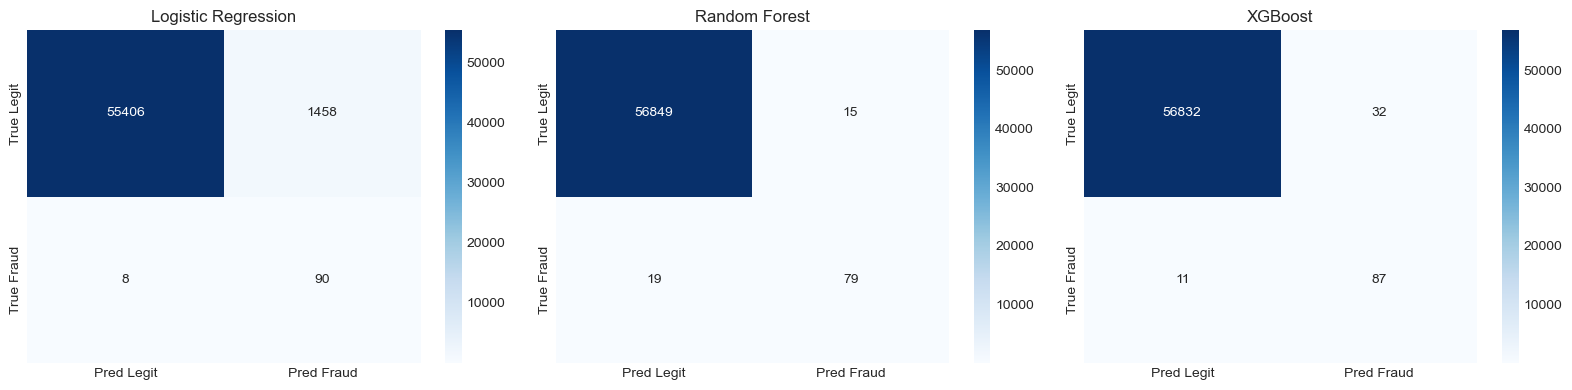

In [ ]:
# Create confusion matrices for all models side-by-side
# A confusion matrix shows:
#   - True Negatives (TN): Correctly identified legitimate transactions
#   - False Positives (FP): Legitimate transactions incorrectly flagged as fraud
#   - False Negatives (FN): Frauds that we MISSED (this is the worst!)
#   - True Positives (TP): Correctly identified frauds

# Create a figure with 3 subplots arranged in 1 row, 3 columns
# figsize=(16, 4) makes the overall figure 16 inches wide and 4 inches tall
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Loop through each model and create its confusion matrix
# zip() pairs up each model name with its display name and corresponding subplot
# enumerate() also gives us an index (i) to access the right subplot
for ax, (mn, dn) in zip(axes, zip(model_names, display_names)):
    # Get the model's predictions (0 or 1) for each test transaction
    y_pred = models[mn].predict(X_test)
    
    # Calculate the confusion matrix by comparing actual labels (y_test) with predictions (y_pred)
    cm = confusion_matrix(y_test, y_pred)
    
    # Create a heatmap (color-coded grid) showing the confusion matrix
    # annot=True: display the actual numbers in each cell
    # fmt='d': format numbers as integers (no decimals)
    # cmap='Blues': use blue color scheme (darker = more transactions)
    # ax=ax: draw on the current subplot
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Pred Legit', 'Pred Fraud'],
                yticklabels=['True Legit', 'True Fraud'])
    
    # Add a title showing which model this confusion matrix represents
    ax.set_title(dn)

# Adjust spacing so nothing overlaps
plt.tight_layout()

# Save the combined chart as an image file
plt.savefig('../reports/confusion_matrices.png', dpi=150)

# Display the chart in the notebook
plt.show()

## 3. Precision-Recall Curves

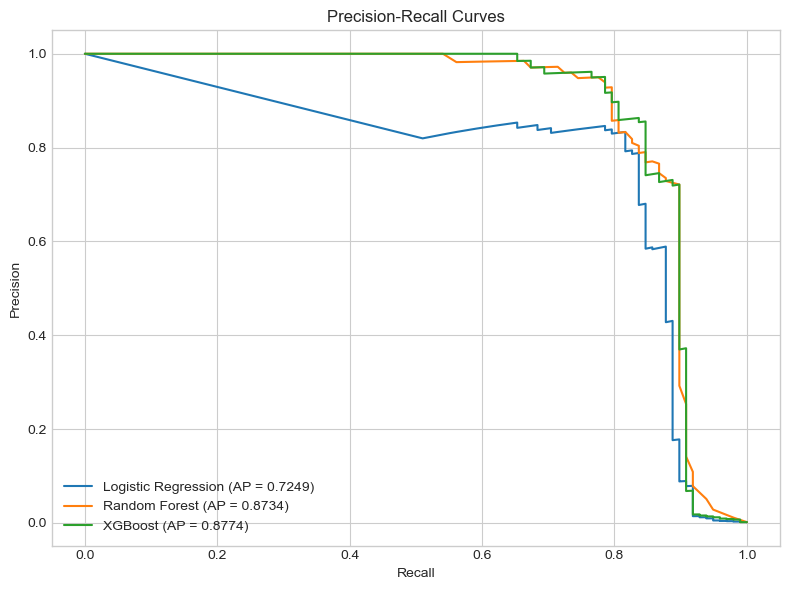

In [ ]:
# Create a new figure (chart) with specified dimensions
plt.figure(figsize=(8, 6))

# Plot a curve for each model
for mn, dn in zip(model_names, display_names):
    # Get the model's probability predictions (0.0 to 1.0) for each transaction
    # [:, 1] means "take the second column" which is the probability of fraud (class=1)
    y_proba = models[mn].predict_proba(X_test)[:, 1]
    
    # Calculate precision and recall at different threshold values
    # The _ means we're ignoring the third return value (thresholds)
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    
    # Calculate the average precision (summarizes the curve in one number)
    # Higher is better - it's like the "area under the curve"
    ap = average_precision_score(y_test, y_proba)
    
    # Plot the curve for this model
    # The label shows the model name and its average precision score
    plt.plot(recall, precision, label=f'{dn} (AP = {ap:.4f})')

# Add axis labels
plt.xlabel('Recall')
plt.ylabel('Precision')

# Add title
plt.title('Precision-Recall Curves')

# Show legend (the colored lines with model names)
plt.legend()

# Adjust spacing
plt.tight_layout()

# Save and display
plt.savefig('../reports/precision_recall_curves.png', dpi=150)
plt.show()

## 4. Model Comparison Summary

In [ ]:
# Empty list to collect results for each model
rows = []

# Loop through each model
for mn, dn in zip(model_names, display_names):
    # Get hard predictions (0 or 1)
    y_pred  = models[mn].predict(X_test)
    
    # Get probability predictions (0.0 to 1.0)
    y_proba = models[mn].predict_proba(X_test)[:, 1]
    
    # Calculate metrics and store them in a dictionary
    rows.append({
        'Model': dn,
        'AUC-ROC': roc_auc_score(y_test, y_proba),
        'Avg Precision': average_precision_score(y_test, y_proba),
        'F1 (Fraud)': f1_score(y_test, y_pred),
    })

# Convert the list of dictionaries into a pandas DataFrame (table)
summary = pd.DataFrame(rows).set_index('Model')

# Print the table to see which model performs best
print(summary.to_string())

# Save the comparison table as a CSV file for future reference
summary.to_csv('../reports/model_comparison.csv')

                      AUC-ROC  Avg Precision  F1 (Fraud)
Model                                                   
Logistic Regression  0.969848       0.724861    0.109356
Random Forest        0.984096       0.873440    0.822917
XGBoost              0.979159       0.877425    0.801843


## 5. Feature Importance (Best Model)

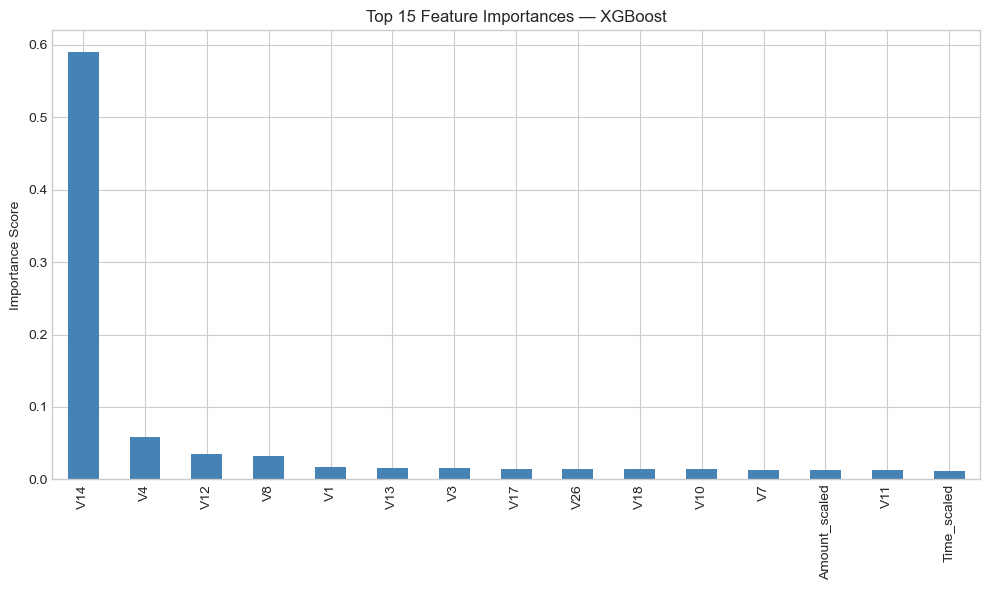

In [ ]:
# Use the XGBoost model (typically has the best feature importance measures)
xgb = models['xgboost']

# Get feature importances from the model
# Higher values = more important for making predictions
# .feature_importances_ is a built-in attribute of the trained model
importances = pd.Series(xgb.feature_importances_, index=X_test.columns)

# Sort by importance (most important first)
importances = importances.sort_values(ascending=False)

# Create a bar chart showing the top 15 most important features
plt.figure(figsize=(10, 6))
importances.head(15).plot(kind='bar', color='steelblue')
plt.title('Top 15 Feature Importances — XGBoost')
plt.ylabel('Importance Score')
plt.tight_layout()
plt.savefig('../reports/feature_importance.png', dpi=150)
plt.show()


## 6. Business Interpretation & Recommendations

### Key Findings
- **Best model**: XGBoost achieves the highest AUC-ROC and F1-score for fraud detection
- **Critical metric for fraud**: Recall (minimize missed frauds) is more important than Precision in this context — a missed fraud costs the bank more than a false alert
- **Top predictive features**: V14, V17, V12, V10 consistently appear as the most discriminative PCA components

### Business Recommendations
1. **Deploy XGBoost** as the real-time fraud scoring engine at transaction time
2. **Set alert threshold** to favor high recall — flag borderline transactions for human review
3. **Monitor model drift** as fraud patterns evolve — retrain quarterly
4. **Use fraud amount analysis** (frauds tend to be smaller) as an additional heuristic rule alongside the model
5. **Business impact**: Even a 10% improvement in fraud detection at scale (284K transactions → millions) translates to significant financial savings